# EDA - Fruit & Veg Quality Dataset
Looking at the Kaggle dataset before training. Need to understand whats in it,
how balanced the classes are, and what the images actually look like.

Dataset: https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')

## Unzip the dataset
uploaded the kaggle zip to drive, extracting it here so its faster to work with

In [3]:
ZIP_PATH = '/content/drive/MyDrive/Advanced_AI/archive.zip'
EXTRACT_TO = '/content/dataset'

# only extract if we havent already (saves time if rerunning)
if not os.path.exists(EXTRACT_TO):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Done')
else:
    print('Already extracted')

Extracting...
Done


## Find the actual image folders
kaggle zips sometimes have extra nested folders so need to find where the actual images are

In [4]:
# walk through the extracted folder until we find where the images actually are
def find_data_root(base_path):
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for root, dirs, files in os.walk(base_path):
        if any(Path(f).suffix.lower() in image_exts for f in files) and len(files) > 10:
            return str(Path(root).parent)
    return base_path

DATA_ROOT = find_data_root(EXTRACT_TO)
print(f'Found data at: {DATA_ROOT}')

# list all the class folders
class_dirs = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d)) and not d.startswith('.')
])

print(f'{len(class_dirs)} class folders found:')
for d in class_dirs:
    count = len([f for f in os.listdir(os.path.join(DATA_ROOT, d))
                 if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])
    print(f'  {d}: {count} images')

Found data at: /content/dataset/Fruit And Vegetable Diseases Dataset
28 class folders found:
  Apple__Healthy: 2438 images
  Apple__Rotten: 2925 images
  Banana__Healthy: 1999 images
  Banana__Rotten: 2797 images
  Bellpepper__Healthy: 611 images
  Bellpepper__Rotten: 591 images
  Carrot__Healthy: 619 images
  Carrot__Rotten: 579 images
  Cucumber__Healthy: 608 images
  Cucumber__Rotten: 593 images
  Grape__Healthy: 200 images
  Grape__Rotten: 200 images
  Guava__Healthy: 200 images
  Guava__Rotten: 200 images
  Jujube__Healthy: 200 images
  Jujube__Rotten: 200 images
  Mango__Healthy: 1813 images
  Mango__Rotten: 2247 images
  Orange__Healthy: 2075 images
  Orange__Rotten: 2186 images
  Pomegranate__Healthy: 200 images
  Pomegranate__Rotten: 200 images
  Potato__Healthy: 614 images
  Potato__Rotten: 584 images
  Strawberry__Healthy: 1603 images
  Strawberry__Rotten: 1596 images
  Tomato__Healthy: 604 images
  Tomato__Rotten: 595 images


## Build a table of all images
need to parse the folder names to figure out which produce type and whether its fresh or rotten.
the folders are named like Apple__Healthy, Banana__Rotten etc

In [5]:
records = []
image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

for class_dir in class_dirs:
    class_path = os.path.join(DATA_ROOT, class_dir)
    dir_lower = class_dir.lower()

    # work out if its fresh or rotten from the folder name
    if 'rotten' in dir_lower or 'stale' in dir_lower or 'diseased' in dir_lower:
        condition = 'rotten'
    elif 'fresh' in dir_lower or 'healthy' in dir_lower:
        condition = 'fresh'
    else:
        condition = 'unknown'

    # get the produce name by stripping out the condition keywords
    produce = dir_lower
    for keyword in ['rotten', 'stale', 'diseased', 'fresh', 'healthy', '_', '-']:
        produce = produce.replace(keyword, ' ')
    produce = ' '.join(produce.split()).strip().title()

    for fname in os.listdir(class_path):
        if Path(fname).suffix.lower() in image_exts:
            records.append({
                'filepath': os.path.join(class_path, fname),
                'filename': fname,
                'class_dir': class_dir,
                'produce': produce,
                'condition': condition,
            })

df = pd.DataFrame(records)
print(f'Total images: {len(df)}')
print(f'Produce types: {df["produce"].nunique()}')
print(f'Fresh vs rotten: {df["condition"].value_counts().to_dict()}')
df.head()

Total images: 29291
Produce types: 14
Fresh vs rotten: {'rotten': 15504, 'fresh': 13787}


,filepath,filename,class_dir,produce,condition
0,/content/dataset/Fruit And Vegetable Diseases ...,freshApple (840).png,Apple__Healthy,Apple,fresh
1,/content/dataset/Fruit And Vegetable Diseases ...,freshApple (731).png,Apple__Healthy,Apple,fresh
2,/content/dataset/Fruit And Vegetable Diseases ...,rotated_by_45_Screen Shot 2018-06-08 at 5.04.4...,Apple__Healthy,Apple,fresh
3,/content/dataset/Fruit And Vegetable Diseases ...,rotated_by_30_Screen Shot 2018-06-08 at 5.01.0...,Apple__Healthy,Apple,fresh
4,/content/dataset/Fruit And Vegetable Diseases ...,rotated_by_60_Screen Shot 2018-06-08 at 5.11.1...,Apple__Healthy,Apple,fresh


## Class distribution
checking if the classes are roughly balanced - if one class has way more images
than another the model might be biased towards it

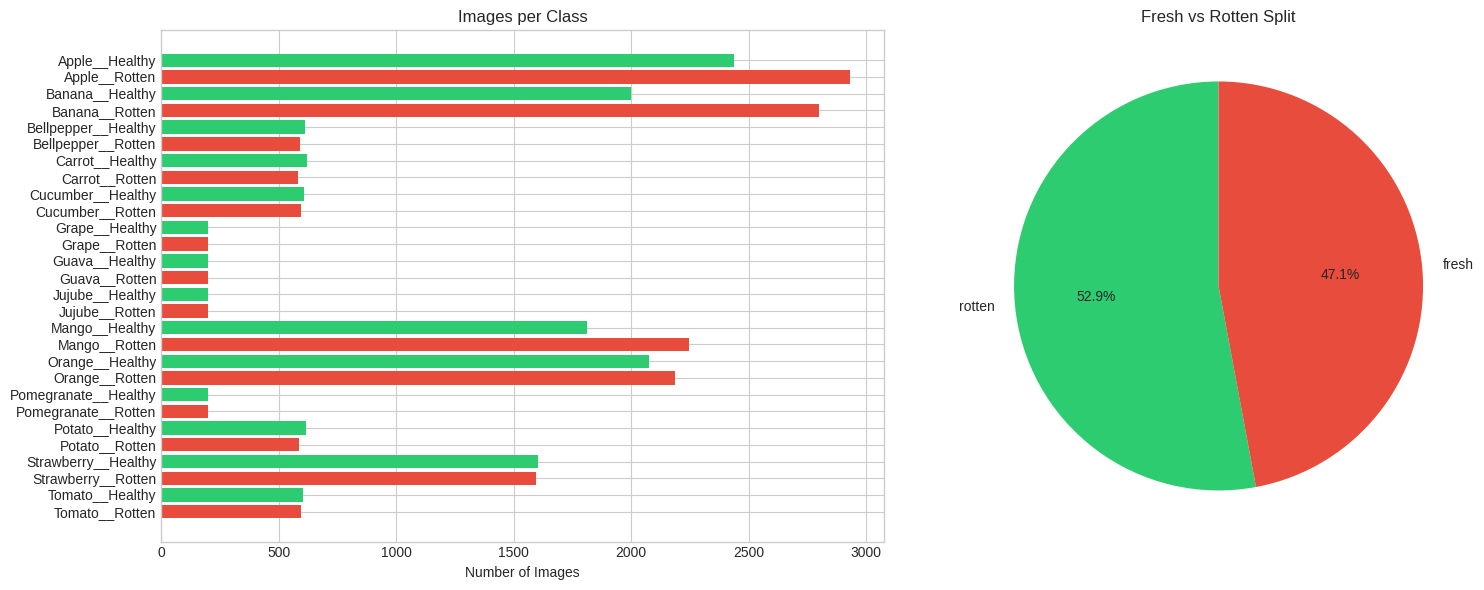

condition    fresh  rotten
produce                   
Apple         2438    2930
Banana        2000    2800
Bellpepper     611     591
Carrot         620     580
Cucumber       608     593
Grape          200     200
Guava          200     200
Jujube         200     200
Mango         1813    2247
Orange        2075    2186
Pomegranate    200     200
Potato         615     585
Strawberry    1603    1596
Tomato         604     596


In [6]:
class_counts = df['class_dir'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# how many images in each class
colors = ['#2ecc71' if 'fresh' in c.lower() or 'healthy' in c.lower() else '#e74c3c' for c in class_counts.index]
axes[0].barh(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel('Number of Images')
axes[0].set_title('Images per Class')
axes[0].invert_yaxis()

# overall fresh vs rotten split
condition_counts = df['condition'].value_counts()
axes[1].pie(condition_counts.values, labels=condition_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Fresh vs Rotten Split')

plt.tight_layout()
plt.show()

# breakdown by produce type
print(df.groupby(['produce', 'condition']).size().unstack(fill_value=0))

## Image sizes
need to know what sizes the images are so i can decide what to resize them to for training.
MobileNetV2 takes 224x224 so thats probably what ill use but want to check theres
nothing weird going on with the dimensions first

Width  - min: 100, max: 4160, avg: 585
Height - min: 100, max: 4160, avg: 523


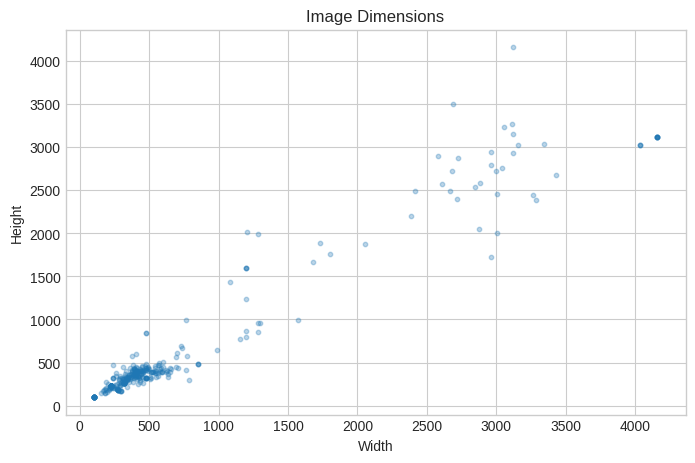

In [7]:
# sample 500 images rather than loading all 29k
sample_df = df.sample(n=500, random_state=42)

widths, heights = [], []
for _, row in sample_df.iterrows():
    try:
        with Image.open(row['filepath']) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        pass

print(f'Width  - min: {min(widths)}, max: {max(widths)}, avg: {np.mean(widths):.0f}')
print(f'Height - min: {min(heights)}, max: {max(heights)}, avg: {np.mean(heights):.0f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(widths, heights, alpha=0.3, s=10)
ax.set_xlabel('Width')
ax.set_ylabel('Height')
ax.set_title('Image Dimensions')
plt.show()

## Visual inspection
looking at actual samples of fresh vs rotten for each produce type.
want to see how obvious the visual differences are - if its easy for a human to tell
them apart then the model should be able to learn it

In [8]:
produce_types = sorted(df['produce'].unique())

fig, axes = plt.subplots(len(produce_types), 2, figsize=(8, 3 * len(produce_types)))
fig.suptitle('Fresh vs Rotten Samples', fontsize=16, y=1.01)

for i, produce in enumerate(produce_types):
    for j, condition in enumerate(['fresh', 'rotten']):
        subset = df[(df['produce'] == produce) & (df['condition'] == condition)]
        if len(subset) > 0:
            row = subset.sample(1, random_state=42).iloc[0]
            try:
                img = Image.open(row['filepath']).resize((224, 224))
                axes[i, j].imshow(img)
            except:
                axes[i, j].text(0.5, 0.5, 'Error', ha='center')
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if j == 0:
            axes[i, j].set_ylabel(produce, fontsize=11)
        if i == 0:
            axes[i, j].set_title(condition.upper(), fontsize=12,
                                 color='green' if condition == 'fresh' else 'red')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Colour analysis
the case study wants a 'Color' score as part of the grading so im looking at whether
theres actually a measurable difference in RGB values between fresh and rotten produce.
if there is then colour features could be useful for the scoring layer later

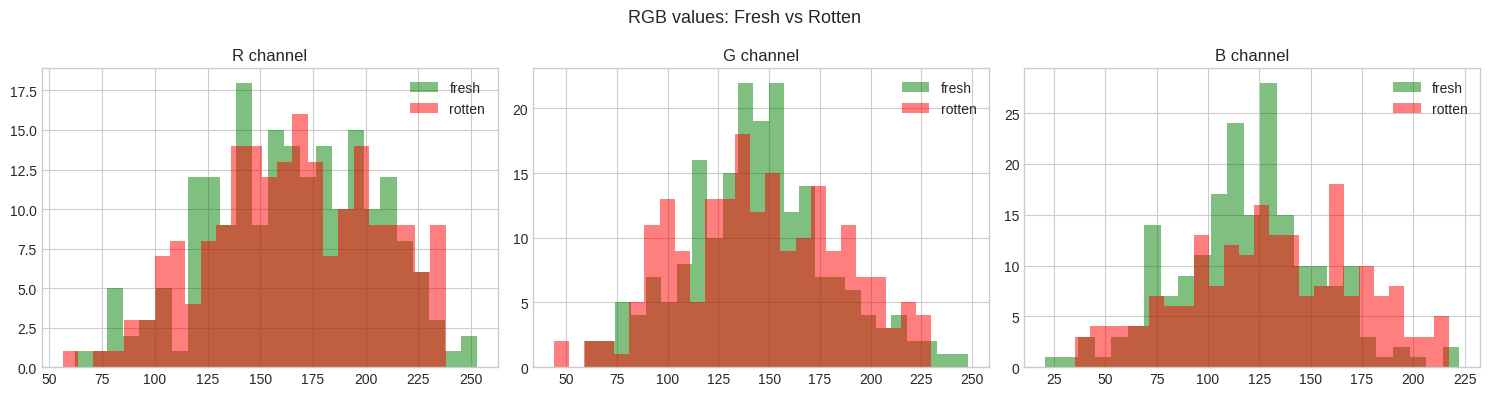

Average values by condition:
           mean_r  mean_g  mean_b  brightness
condition                                    
fresh       164.8   144.5   119.4       142.9
rotten      165.7   145.8   130.9       147.5


In [9]:
colour_data = []

for condition in ['fresh', 'rotten']:
    subset = df[df['condition'] == condition].sample(n=200, random_state=42)
    for _, row in subset.iterrows():
        try:
            img = Image.open(row['filepath']).convert('RGB').resize((64, 64))
            arr = np.array(img)
            colour_data.append({
                'condition': condition,
                'mean_r': arr[:,:,0].mean(),
                'mean_g': arr[:,:,1].mean(),
                'mean_b': arr[:,:,2].mean(),
                'brightness': arr.mean(),
            })
        except:
            pass

colour_df = pd.DataFrame(colour_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (channel, color) in enumerate([('mean_r', 'red'), ('mean_g', 'green'), ('mean_b', 'blue')]):
    for cond in ['fresh', 'rotten']:
        data = colour_df[colour_df['condition'] == cond][channel]
        axes[i].hist(data, bins=25, alpha=0.5, label=cond,
                     color='green' if cond == 'fresh' else 'red')
    axes[i].set_title(f'{channel.split("_")[1].upper()} channel')
    axes[i].legend()

plt.suptitle('RGB values: Fresh vs Rotten', fontsize=13)
plt.tight_layout()
plt.show()

print('Average values by condition:')
print(colour_df.groupby('condition')[['mean_r', 'mean_g', 'mean_b', 'brightness']].mean().round(1))

## Key findings

- 29,291 images total across 14 produce types
- 28 classes (14 fresh + 14 rotten)
- overall split is roughly 47% fresh / 53% rotten which is close enough to balanced
- some produce types have way more images than others (apples/bananas ~2500+, grapes/guava only ~200)
- the visual difference between fresh and rotten is pretty obvious in most cases which is good
- there does seem to be some difference in RGB values between fresh and rotten which supports using colour as a feature for the scoring

## Plan for training
- resize to 224x224 (what MobileNetV2 expects)
- use transfer learning with MobileNetV2 pretrained on ImageNet
- binary classification: fresh vs rotten
- use augmentation (flips, rotation, brightness) to help with the smaller classes and prevent overfitting
- build a separate scoring layer for the Color/Size/Ripeness grades after

In [10]:
# save the metadata so notebook 2 can use it
df.to_csv('/content/drive/MyDrive/Advanced_AI/image_metadata.csv', index=False)
print(f'Saved metadata for {len(df)} images')

Saved metadata for 29291 images
